## Test preprocessing

Ce notebook teste l'intégrité des données générée par le processus de preprocess

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)
dataset_test = IndexedDataset.create(config, DatasetType.TEST)
dataset_validation = IndexedDataset.create(config, DatasetType.VALIDATION)

In [5]:
# validation quantite de labels
assert len(dataset_train.species_label) == 5
assert len(dataset_test.species_label) == 5
assert len(dataset_validation.species_label) == 5

In [6]:
# inspection visuelle
print(dataset_train.species_label)
print(len(dataset_train.species_label))

['Barn Swallow', 'Common Buzzard', 'Western Yellow Wagtail', 'Thrush Nightingale', 'Willow Warbler']
5


In [7]:
group_length, segment_length_, group_hop_length = config.preprocess.group_frame_infos()
print(group_length, segment_length_, group_hop_length)

110 30 20


In [8]:
# train
print(dataset_train.spectrogram_groups.shape)
print("min:", np.min(dataset_train.spectrogram_groups), ", max:", np.max(dataset_train.spectrogram_groups))
print(dataset_train.y.shape)
print(dataset_train.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_train.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_train_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_train.lat_long.shape == (num_samples, 2)

np.unique( dataset_train.y )

(4116, 5, 100, 30)
min: -1.0 , max: 4.7134968e-08
(4116, 5)
[[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]]


array([0, 1], dtype=int16)

In [9]:
# test
print(dataset_test.spectrogram_groups.shape)
print("min:", np.min(dataset_test.spectrogram_groups), ", max:", np.max(dataset_test.spectrogram_groups))
print(dataset_test.y.shape)
print(dataset_test.y[:3])

num_samples, group_segment_count, n_mels, segment_length = dataset_test.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_test_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_test.lat_long.shape == (num_samples, 2)

np.unique( dataset_test.y )

(1372, 5, 100, 30)
min: -1.0 , max: 4.7117823e-08
(1372, 5)
[[0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [10]:
# validation
print(dataset_validation.spectrogram_groups.shape)
print("min:", np.min(dataset_validation.spectrogram_groups), ", max:", np.max(dataset_validation.spectrogram_groups))
print(dataset_validation.y.shape)
print(dataset_validation.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_validation.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * (1 - config.preprocess.split_train_size - config.preprocess.split_test_size)
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_validation.lat_long.shape == (num_samples, 2)

np.unique( dataset_validation.y )

(1372, 5, 100, 30)
min: -1.0 , max: 4.594176e-08
(1372, 5)
[[0 0 0 1 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [11]:
# validation distribution
print( np.sum( dataset_train.y, axis=0 ) / dataset_train.y.shape[0] )
print( np.sum( dataset_test.y, axis=0 ) / dataset_test.y.shape[0] )
print( np.sum( dataset_validation.y, axis=0 ) / dataset_validation.y.shape[0] )

[0.19995141 0.20019436 0.19995141 0.19995141 0.19995141]
[0.20043732 0.19970845 0.19970845 0.19970845 0.20043732]
[0.19970845 0.19970845 0.20043732 0.20043732 0.19970845]


In [12]:
import librosa as rosa
from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import _SPECTROGRAM

def specshow(data):
    if True:
        rosa.display.specshow(data,
                              x_axis='time',
                              y_axis='mel',
                              sr=config.preprocess.clip_sampling_rate_hz,
                              ax=plt.gca(),
                              n_fft=config.preprocess.spectrogram_n_ftt,
                              hop_length=config.preprocess.spectrogram_hop_length,
                              cmap="gray_r")
    else:
        plt.gca().imshow(data,
                         cmap="gray",
                         aspect="auto",
                         interpolation="nearest",
                         vmin=0.0,
                         vmax=1.0)

def plot_group(path, start, stop):
    with open_file(path, "r") as file:
        data = file[_SPECTROGRAM]
        fig = plt.figure(figsize=(12, 2.5))
        specshow(data[:, start:stop])
        plt.title(f"Group {path.name}, ({start}, {stop})")
        plt.tight_layout()
        plt.show()

def plot_segments(data):
    fig = plt.figure(figsize=(12, 2.5))

    num_segments = data.shape[0]
    for s in range(num_segments):
        subplot = f"1{num_segments}{s + 1}"
        plt.subplot( int(subplot) )
        specshow(data[s])
        plt.xlabel("")

    plt.suptitle("Segments")
    plt.tight_layout()
    plt.show()

    # assert not np.allclose(data[0], data[1])
    # assert not np.allclose(data[0], data[2])
    # assert not np.allclose(data[1], data[2])

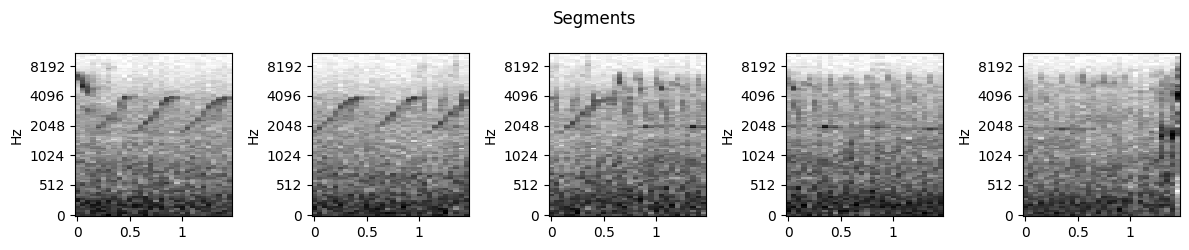

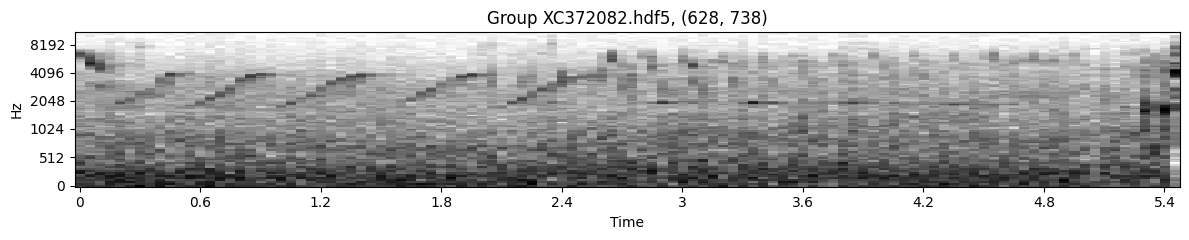

In [13]:
# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_validation.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC372082.hdf5, 1367, 0, (628, 658)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC372082.hdf5, 1367, 1, (648, 678)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC372082.hdf5, 1367, 2, (668, 698)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC372082.hdf5, 1367, 3, (688, 718)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/wlwwar/XC372082.hdf5, 1367, 4, (708, 738)

plot_segments( dataset_validation.spectrogram_groups[1367] )
plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "wlwwar/XC372082.hdf5"),
           628,
           738)

In [14]:
assert dataset_validation.spectrogram_groups.is_virtual

print(dataset_validation.spectrogram_groups[0, 0].shape, config.preprocess.clip_sampling_rate_hz)
print()
print( config.preprocess.group_frame_infos() )
print( config.preprocess.group_ms_infos() )
print()

(100, 30) 22050

(110, 30, 20)
(5500, 1500, 1000)

